# Post-COVID Rent Trends in the United States

This analysis examines U.S. county-level rent trends before and after the onset of COVID-19 using Zillow Observed Rent Index (ZORI) data, supplemented with publicly available U.S. government data accessed via API.

The goal is to explore how rental markets shifted during and after the pandemic, identify geographic and temporal patterns in housing costs, and highlight regional variation in post-COVID rent trends.


## 1. Data Collection


###  Problem Statement
This analysis examines housing affordability in the United States by comparing median household income with rental housing costs at the county level over time. Publicly available income data from the U.S. Census Bureau’s American Community Survey and rental price data from Zillow are collected and combined to create a unified dataset.

By cleaning, restructuring, and merging these sources, the analysis explores how rental housing costs have shifted relative to income in the post-COVID period.


## Dataset 1: American Community Survey (ACS) Median Household Income

### Data Source and Collection Method

Median household income data were retrieved programmatically using the U.S. Census Bureau’s public API. Specifically, data from the American Community Survey (ACS) were accessed to obtain county-level estimates of median household income across the United States.


### Key Variables

- **B19013_001E** — Estimated median household income
- **state** — State FIPS code
- **county** — County FIPS code


In [1]:
# Retrieve ACS median household income data via the U.S. Census Bureau API

import requests
import pandas as pd

# ACS 5-year estimate vintages to retrieve
years = range(2019, 2024)

# Collect yearly results
acs_frames = []

for year in years:
    # Census API endpoint for ACS 5-year estimates
    url = f"https://api.census.gov/data/{year}/acs/acs5"
    
    # Request median household income by county
    census_request = {
        "get": "NAME,B19013_001E",
        "for": "county:*",
        "in": "state:*"
    }

    # Execute API request
    response = requests.get(url, params=census_request)
    response.raise_for_status()

    # Parse JSON response
    acs_data = response.json()

    # Load results into DataFrame
    df = pd.DataFrame(acs_data[1:], columns=acs_data[0])

    # Add year identifier
    df["year"] = year

    acs_frames.append(df)

# Combine all years into a single DataFrame
income_df = pd.concat(acs_frames, ignore_index=True)

# Basic inspection
print(income_df.head())
print(income_df.info())
print(income_df["year"].value_counts().sort_index())


                       NAME B19013_001E state county  year
0  Fayette County, Illinois       46650    17    051  2019
1    Logan County, Illinois       57308    17    107  2019
2   Saline County, Illinois       44090    17    165  2019
3     Lake County, Illinois       89427    17    097  2019
4   Massac County, Illinois       47481    17    127  2019
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16106 entries, 0 to 16105
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   NAME         16106 non-null  object
 1   B19013_001E  16106 non-null  object
 2   state        16106 non-null  object
 3   county       16106 non-null  object
 4   year         16106 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 629.3+ KB
None
year
2019    3220
2020    3221
2021    3221
2022    3222
2023    3222
Name: count, dtype: int64


## Dataset 2: Zillow Observed Rent Index (ZORI)

### Data Source and Collection Method
Rental price data were obtained from Zillow in the form of a publicly available CSV file containing county-level rent estimates over time. The dataset provides monthly rental price observations and enables analysis of temporal trends in housing costs across U.S. counties.

### Key Variables
- **RegionName** — Name of the U.S. county associated with each rental price observation
- **State** — U.S. state in which the county is located
- **date** — Month and year of the rental price observation
- **rent** — Observed rental price value for the specified county and time period


In [2]:
# Load Zillow Observed Rent Index (ZORI) data from CSV

zillow_df = pd.read_csv("County_zori.csv")

# Basic inspection
print(zillow_df.head())
print(zillow_df.info())


   RegionID  SizeRank          RegionName RegionType StateName State  \
0      3101         0  Los Angeles County     county        CA    CA   
1       139         1         Cook County     county        IL    IL   
2      1090         2       Harris County     county        TX    TX   
3      2402         3     Maricopa County     county        AZ    AZ   
4      2841         4    San Diego County     county        CA    CA   

                                  Metro  StateCodeFIPS  MunicipalCodeFIPS  \
0    Los Angeles-Long Beach-Anaheim, CA              6                 37   
1    Chicago-Naperville-Elgin, IL-IN-WI             17                 31   
2  Houston-The Woodlands-Sugar Land, TX             48                201   
3             Phoenix-Mesa-Chandler, AZ              4                 13   
4    San Diego-Chula Vista-Carlsbad, CA              6                 73   

    2015-01-31  ...   2025-02-28   2025-03-31   2025-04-30   2025-05-31  \
0  1705.379560  ...  2793.794

In [3]:
# Persist raw source datasets locally for reproducibility

import os

# Create local data directory if it does not exist
os.makedirs("data", exist_ok=True)

# Save raw ACS income data
income_df.to_csv("data/acs_income_raw.csv", index=False)

# Save raw Zillow ZORI data
zillow_df.to_csv("data/zillow_zori_raw.csv", index=False)


## Data Assessment

### Initial Data Inspection

An initial inspection was performed to assess data structure, completeness, and potential quality issues in the ACS income dataset. This step helps identify missing values, inconsistent formats, and structural issues that could affect downstream analysis.


In [4]:
# Inspect ACS income data structure and sample records
income_df.head()


,NAME,B19013_001E,state,county,year
0,"Fayette County, Illinois",46650,17,051,2019
1,"Logan County, Illinois",57308,17,107,2019
2,"Saline County, Illinois",44090,17,165,2019
3,"Lake County, Illinois",89427,17,097,2019
4,"Massac County, Illinois",47481,17,127,2019


In [5]:
# Inspect structure, data types, and missing values in ACS income data
print(income_df.info())

# Check for missing values
income_df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16106 entries, 0 to 16105
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   NAME         16106 non-null  object
 1   B19013_001E  16106 non-null  object
 2   state        16106 non-null  object
 3   county       16106 non-null  object
 4   year         16106 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 629.3+ KB
None


NAME           0
B19013_001E    0
state          0
county         0
year           0
dtype: int64

### Income Variable Labeling and Data Type

The median household income variable is labeled using its ACS variable code (`B19013_001E`), which reduces readability and interpretability. In addition, the column is stored as an object rather than a numeric data type, limiting its usefulness for analysis and aggregation.

Programmatic inspection indicates that no missing values are present in the ACS income data at this stage. The income variable will be renamed and converted to a numeric type during the data cleaning step.


### Missing Values and Incomplete Time Series Coverage

Inspection of the Zillow rent dataset shows that many counties contain missing rental values, particularly in earlier months of the time series. These missing values are concentrated in the early portion of the dataset (notably 2015), indicating incomplete historical coverage rather than random missingness.

This pattern limits direct comparisons across time for all counties and will be addressed during the data cleaning step through filtering or aggregation to ensure consistent time series coverage.


In [6]:
# Inspect structure and sample records of Zillow rent data
zillow_df.head()


,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,2015-01-31,...,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30
0,3101,0,Los Angeles County,county,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",6,37,1705.379560,...,2793.794764,2817.746483,2812.126891,2813.321476,2814.163151,2817.355735,2818.258792,2819.255129,2817.011764,2809.350347
1,139,1,Cook County,county,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",17,31,1395.982083,...,2028.786447,2050.358934,2074.105489,2095.414906,2115.220224,2126.476864,2129.909393,2127.073085,2119.449253,2113.407616
2,1090,2,Harris County,county,TX,TX,"Houston-The Woodlands-Sugar Land, TX",48,201,1171.944553,...,1590.184352,1599.527570,1604.476965,1604.990756,1596.330612,1595.755035,1594.559833,1597.147871,1590.505824,1583.635520
3,2402,3,Maricopa County,county,AZ,AZ,"Phoenix-Mesa-Chandler, AZ",4,13,922.131988,...,1756.595867,1766.064444,1769.316512,1766.080133,1763.230055,1760.232282,1755.398077,1751.261019,1744.452843,1736.139446
4,2841,4,San Diego County,county,CA,CA,"San Diego-Chula Vista-Carlsbad, CA",6,73,1629.385232,...,2901.359856,2918.642135,2927.121691,2936.365503,2944.664923,2949.613282,2955.408082,2952.840170,2948.825242,2932.813719


In [7]:
# Inspect data types and memory usage
print(zillow_df.info())

# Count counties with at least one missing rental value
(zillow_df.isna().any(axis=1)).sum()

# Identify columns (months) with the highest number of missing values
zillow_df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Columns: 140 entries, RegionID to 2025-11-30
dtypes: float64(131), int64(4), object(5)
memory usage: 1.3+ MB
None


2015-01-31    836
2015-02-28    834
2015-03-31    824
2015-05-31    821
2015-04-30    820
2015-07-31    819
2015-08-31    817
2015-06-30    817
2015-09-30    816
2015-10-31    812
dtype: int64

Issue and justification: Programmatic inspection shows that 864 counties contain at least one missing rental value. Missing values are concentrated in earlier months (particularly 2015), indicating incomplete time series coverage rather than random gaps. These missing values limit comparisons across time and will be addressed during the cleaning step through filtering or aggregation.

### Wide Time-Series Structure in Zillow Rent Data


In [8]:
# Inspect structure and dimensionality of Zillow rent data
print(zillow_df.head())
print(zillow_df.shape)


   RegionID  SizeRank          RegionName RegionType StateName State  \
0      3101         0  Los Angeles County     county        CA    CA   
1       139         1         Cook County     county        IL    IL   
2      1090         2       Harris County     county        TX    TX   
3      2402         3     Maricopa County     county        AZ    AZ   
4      2841         4    San Diego County     county        CA    CA   

                                  Metro  StateCodeFIPS  MunicipalCodeFIPS  \
0    Los Angeles-Long Beach-Anaheim, CA              6                 37   
1    Chicago-Naperville-Elgin, IL-IN-WI             17                 31   
2  Houston-The Woodlands-Sugar Land, TX             48                201   
3             Phoenix-Mesa-Chandler, AZ              4                 13   
4    San Diego-Chula Vista-Carlsbad, CA              6                 73   

    2015-01-31  ...   2025-02-28   2025-03-31   2025-04-30   2025-05-31  \
0  1705.379560  ...  2793.794

In [9]:
# Identify columns representing monthly rent values
date_columns = zillow_df.columns[zillow_df.columns.str.match(r"\d{4}-\d{2}-\d{2}")]
len(date_columns)


131



The Zillow dataset contains 131 date-labeled columns representing monthly rent values. This wide table structure stores time information in column names rather than as a variable, resulting in multiple columns representing the same measurement across different months.

This structure makes filtering, aggregation, and time-based analysis more difficult. To support trend analysis and integration with income data, the dataset will be reshaped into a long (tidy) format during the data cleaning step.


### Mismatched Time Granularity Between Income and Rent Data


In [10]:
# Compare structure of ACS income data and Zillow rent data
print(income_df.head())
print(zillow_df.head())


                       NAME B19013_001E state county  year
0  Fayette County, Illinois       46650    17    051  2019
1    Logan County, Illinois       57308    17    107  2019
2   Saline County, Illinois       44090    17    165  2019
3     Lake County, Illinois       89427    17    097  2019
4   Massac County, Illinois       47481    17    127  2019
   RegionID  SizeRank          RegionName RegionType StateName State  \
0      3101         0  Los Angeles County     county        CA    CA   
1       139         1         Cook County     county        IL    IL   
2      1090         2       Harris County     county        TX    TX   
3      2402         3     Maricopa County     county        AZ    AZ   
4      2841         4    San Diego County     county        CA    CA   

                                  Metro  StateCodeFIPS  MunicipalCodeFIPS  \
0    Los Angeles-Long Beach-Anaheim, CA              6                 37   
1    Chicago-Naperville-Elgin, IL-IN-WI             17     

In [11]:
# Inspect ACS data dimensions
print(income_df.shape)

# Confirm number of monthly rent columns in Zillow data
print(len(date_columns))


(16106, 5)
131


### Mismatched Time Granularity Between Income and Rent Data

The ACS income dataset provides a single annual median household income value per county, while the Zillow dataset reports rental values at a monthly level across multiple years. As a result, the two datasets operate at different time granularities.

This mismatch prevents direct comparison of income and rent values without restructuring. During the data cleaning step, the time dimensions will be aligned to ensure that income and rental data are comparable within the same temporal framework.


## Data Cleaning and Preparation
This section applies targeted cleaning and restructuring steps to address the data quality and tidiness issues identified during assessment. The goal is to produce a consistent, analysis-ready dataset suitable for comparing income and rent trends over time.


In [12]:
# Create working copies of source datasets for cleaning
income_clean = income_df.copy()
zillow_clean = zillow_df.copy()


### Standardizing Income Variable Names and Data Types

The ACS income variable was renamed to improve readability and converted from an object to a numeric data type to support aggregation and comparison. This ensures that income values can be used reliably in downstream analysis alongside rental price data.


In [13]:
# Rename income column for clarity
income_clean = income_clean.rename(
    columns={"B19013_001E": "median_household_income"}
)

# Convert income values to numeric type
income_clean["median_household_income"] = pd.to_numeric(
    income_clean["median_household_income"], errors="coerce"
)

# Validate data types and missing values
print(income_clean.info())
print(income_clean.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16106 entries, 0 to 16105
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NAME                     16106 non-null  object
 1   median_household_income  16106 non-null  int64 
 2   state                    16106 non-null  object
 3   county                   16106 non-null  object
 4   year                     16106 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 629.3+ KB
None
NAME                       0
median_household_income    0
state                      0
county                     0
year                       0
dtype: int64


### Reducing Missing Rental Values by Limiting Early Time Periods

Rental price data contain substantial missing values, primarily concentrated in earlier years of the Zillow time series. To improve data completeness and align with the post-COVID analysis focus, the dataset was restricted to observations from 2019 onward.

This filtering step reduces missingness while preserving sufficient temporal coverage for analysis. Remaining missing values will be addressed after reshaping the dataset into a tidy format.


In [14]:
# Identify monthly date columns in Zillow data
date_columns = zillow_clean.columns[
    zillow_clean.columns.str.match(r"\d{4}-\d{2}-\d{2}")
]

# Retain data from 2019 onward to reduce early missing coverage
keep_date_columns = [c for c in date_columns if c >= "2019-01-01"]

# Preserve identifier columns and filtered date columns
id_columns = [c for c in zillow_clean.columns if c not in date_columns]
zillow_clean = zillow_clean[id_columns + keep_date_columns]

# Validate reduction in missing values after filtering
counties_with_missing = (zillow_clean.isna().any(axis=1)).sum()
total_counties = zillow_clean.shape[0]

print(zillow_clean.shape)
print(
    counties_with_missing,
    "counties with at least one missing value out of",
    total_counties,
)


(1229, 92)
718 counties with at least one missing value out of 1229


### Reshaping Zillow Rent Data into Tidy Format

Zillow rent values were originally distributed across many date-labeled columns, with time embedded in column names. To support time-based analysis and integration with income data, the dataset was reshaped so that each row represents a single county-month observation.

This transformation stores time and rent values as explicit variables, enabling filtering, aggregation, and comparison across periods.


In [15]:
# Identify monthly date columns
date_columns = zillow_clean.columns[
    zillow_clean.columns.str.match(r"\d{4}-\d{2}-\d{2}")
]

# Reshape Zillow data from wide to long format
zillow_clean = zillow_clean.melt(
    id_vars=[c for c in zillow_clean.columns if c not in date_columns],
    value_vars=date_columns,
    var_name="date",
    value_name="rent"
)

# Convert date column to datetime
zillow_clean["date"] = pd.to_datetime(zillow_clean["date"])

# Validate structure after reshaping
print(zillow_clean.head())
print(zillow_clean.info())


   RegionID  SizeRank          RegionName RegionType StateName State  \
0      3101         0  Los Angeles County     county        CA    CA   
1       139         1         Cook County     county        IL    IL   
2      1090         2       Harris County     county        TX    TX   
3      2402         3     Maricopa County     county        AZ    AZ   
4      2841         4    San Diego County     county        CA    CA   

                                  Metro  StateCodeFIPS  MunicipalCodeFIPS  \
0    Los Angeles-Long Beach-Anaheim, CA              6                 37   
1    Chicago-Naperville-Elgin, IL-IN-WI             17                 31   
2  Houston-The Woodlands-Sugar Land, TX             48                201   
3             Phoenix-Mesa-Chandler, AZ              4                 13   
4    San Diego-Chula Vista-Carlsbad, CA              6                 73   

        date         rent  
0 2019-01-31  2170.219099  
1 2019-01-31  1541.860229  
2 2019-01-31  1278.0

### Aligning Monthly Rent Data with Annual Income Data

Zillow rental prices are reported at a monthly level, while ACS income data are reported annually. To enable direct comparison between income and rent, monthly rental values were aggregated to annual mean rent by county and year.

This transformation aligns the temporal structure of both datasets and supports consistent year-over-year analysis of housing affordability in the post-COVID period.


In [16]:
# Extract year from date
zillow_clean["year"] = zillow_clean["date"].dt.year

# Aggregate monthly rent to annual mean by county and year
zillow_annual = zillow_clean.groupby(
    ["StateCodeFIPS", "MunicipalCodeFIPS", "year"],
    as_index=False
).agg(
    annual_rent=("rent", "mean")
)

# Validate aggregated structure and coverage
print(zillow_annual.head())
print(zillow_annual.info())

# Confirm year coverage
zillow_annual["year"].value_counts().sort_index()


   StateCodeFIPS  MunicipalCodeFIPS  year  annual_rent
0              1                  1  2019          NaN
1              1                  1  2020          NaN
2              1                  1  2021  1450.970984
3              1                  1  2022  1496.242852
4              1                  1  2023  1564.946775
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8603 entries, 0 to 8602
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StateCodeFIPS      8603 non-null   int64  
 1   MunicipalCodeFIPS  8603 non-null   int64  
 2   year               8603 non-null   int32  
 3   annual_rent        5578 non-null   float64
dtypes: float64(1), int32(1), int64(2)
memory usage: 235.4 KB
None


year
2019    1229
2020    1229
2021    1229
2022    1229
2023    1229
2024    1229
2025    1229
Name: count, dtype: int64

### Combining Income and Rent Data by County and Year

To compare income and rent consistently, both datasets are reduced to the required fields and merged using county FIPS codes and year. Merge keys are standardized to preserve leading zeros and ensure reliable joins.


In [17]:
# Keep only needed columns
income_combined = income_clean[["state", "county", "year", "median_household_income"]].copy()
zillow_combined = zillow_annual[["StateCodeFIPS", "MunicipalCodeFIPS", "year", "annual_rent"]].copy()

# Align merge-key dtypes (FIPS codes as zero-padded strings)
income_combined["state"] = income_combined["state"].astype(str).str.zfill(2)
income_combined["county"] = income_combined["county"].astype(str).str.zfill(3)

zillow_combined["StateCodeFIPS"] = zillow_combined["StateCodeFIPS"].astype(str).str.zfill(2)
zillow_combined["MunicipalCodeFIPS"] = zillow_combined["MunicipalCodeFIPS"].astype(str).str.zfill(3)

# Merge on county FIPS + year
combined_df = pd.merge(
    income_combined,
    zillow_combined,
    left_on=["state", "county", "year"],
    right_on=["StateCodeFIPS", "MunicipalCodeFIPS", "year"],
    how="inner"
)

# Drop duplicate key columns from right side after merge
combined_df = combined_df.drop(columns=["StateCodeFIPS", "MunicipalCodeFIPS"])

# Quick check
print(combined_df.head())
print(combined_df.info())
print(combined_df["year"].value_counts().sort_index())


  state county  year  median_household_income  annual_rent
0    17    097  2019                    89427  1426.358402
1    18    157  2019                    53130  1004.703362
2    18    057  2019                    98173  1287.197108
3    18    005  2019                    63431   948.572202
4    18    113  2019                    56789          NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6129 entries, 0 to 6128
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state                    6129 non-null   object 
 1   county                   6129 non-null   object 
 2   year                     6129 non-null   int64  
 3   median_household_income  6129 non-null   int64  
 4   annual_rent              3364 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 239.5+ KB
None
year
2019    1229
2020    1229
2021    1229
2022    1221
2023    1221
Name: count, dtype: int

### Assessing Missing Rent Coverage After Merge

Zillow does not provide complete county-level rent coverage for all counties and years present in the ACS dataset. After merging, missing `annual_rent` values are quantified to understand coverage limitations and inform the cleaning strategy.


In [18]:
# Identify missing rent values after merge
missing_rent = combined_df["annual_rent"].isna().sum()
total_rows = len(combined_df)

print("Missing annual_rent:", missing_rent)
print("Percent missing annual_rent:", round(missing_rent / total_rows * 100, 2), "%")
print(combined_df.groupby("year")["annual_rent"].apply(lambda s: s.isna().sum()))


Missing annual_rent: 2765
Percent missing annual_rent: 45.11 %
year
2019    675
2020    661
2021    605
2022    469
2023    355
Name: annual_rent, dtype: int64


Because `annual_rent` is required for comparing rent to income, rows with missing rental values were removed from the analysis dataset. Imputation was not performed, since counties without Zillow coverage do not have enough information to estimate rent values reliably without introducing bias.


## Persisting Cleaned Data

The final analysis-ready dataset is saved separately from raw source data to preserve data lineage and reproducibility. Only records with complete income and rent information are retained in the cleaned dataset.


In [19]:
# Create the cleaned, analysis-ready dataset
combined_clean = combined_df.dropna(subset=["annual_rent"]).copy()

# Validate row counts and missing values
print("Rows before:", combined_df.shape[0])
print("Rows after:", combined_clean.shape[0])
print(combined_clean.isna().sum())

# Save cleaned dataset
combined_clean.to_csv(
    "acs_zillow_income_rent_clean.csv",
    index=False
)


Rows before: 6129
Rows after: 3364
state                      0
county                     0
year                       0
median_household_income    0
annual_rent                0
dtype: int64


Raw source datasets were saved earlier in the workflow to preserve original data. The cleaned, merged dataset is saved here as `acs_zillow_income_rent_clean.csv` and is used for all downstream analysis.


## Trends in Income and Rent After COVID-19

This section examines how county-level median household income and annual rental prices changed between 2019 and 2023, spanning the period before and after the onset of the COVID-19 pandemic.


**Research question:**  
How have county-level median household income and annual rental prices in the United States changed from 2019 to 2023, the period spanning before and after the COVID-19 pandemic?


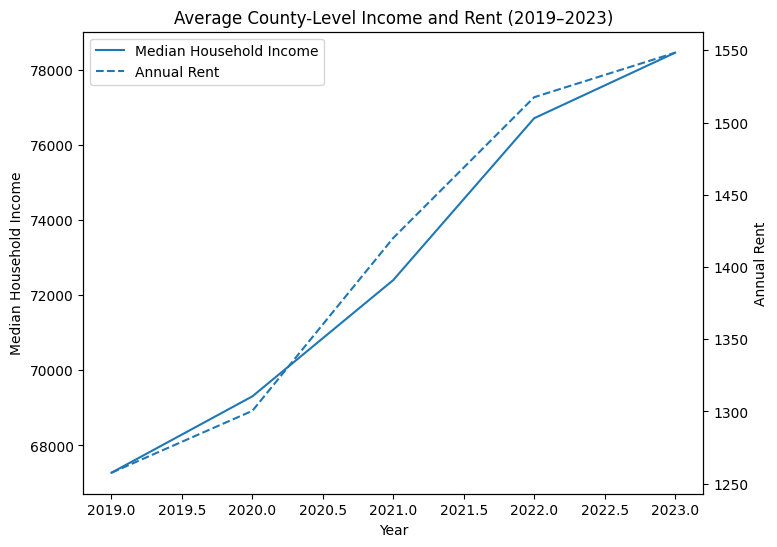

In [20]:
import matplotlib.pyplot as plt

yearly_avg = (
    combined_clean
    .groupby("year")[["median_household_income", "annual_rent"]]
    .mean()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8, 6))

# Median household income (left axis)
ax1.plot(
    yearly_avg["year"],
    yearly_avg["median_household_income"],
    label="Median Household Income"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Median Household Income")

# Annual rent (right axis)
ax2 = ax1.twinx()
ax2.plot(
    yearly_avg["year"],
    yearly_avg["annual_rent"],
    linestyle="--",
    label="Annual Rent"
)
ax2.set_ylabel("Annual Rent")

plt.title("Average County-Level Income and Rent (2019–2023)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()



This visualization shows average county-level median household income and annual rental prices from 2019 to 2023. Median household income increased steadily over the period, with more pronounced growth after 2020. Annual rental prices also rose, with sharper increases beginning after 2021.

Together, these trends indicate that both income and housing costs increased in the years following the onset of the COVID-19 pandemic, with rental prices accelerating more rapidly in the later post-COVID period.


### Changes in Rent Burden Over Time


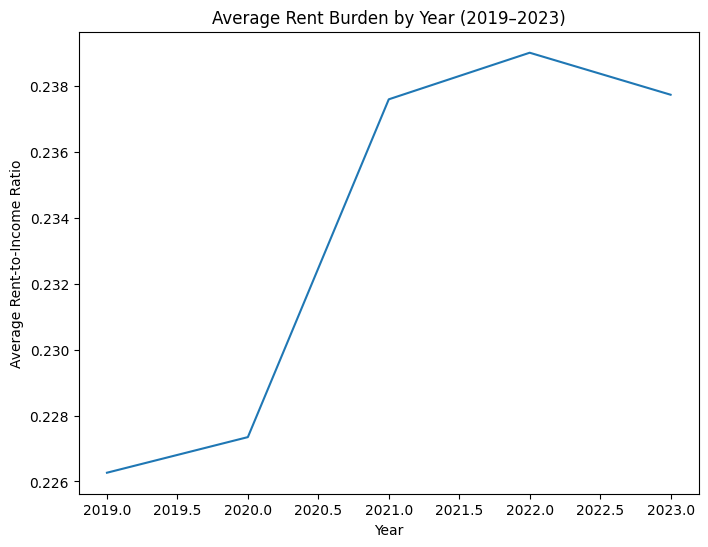

In [21]:
# Calculate rent-to-income ratio as a proxy for housing affordability
df = combined_clean.copy()
df["rent_share"] = (df["annual_rent"] * 12) / df["median_household_income"]

# Compute yearly average rent burden
rent_share_yearly = (
    df.groupby("year")["rent_share"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 6))
plt.plot(
    rent_share_yearly["year"],
    rent_share_yearly["rent_share"]
)
plt.xlabel("Year")
plt.ylabel("Average Rent-to-Income Ratio")
plt.title("Average Rent Burden by Year (2019–2023)")
plt.show()


This visualization shows the average rent-to-income ratio by year, using annual rent as a share of median household income. The ratio increased notably after 2020, indicating that housing costs consumed a larger portion of household income in the post-COVID period.

Although the ratio declined slightly in 2023, it remained above pre-COVID levels, suggesting persistent affordability pressure despite income growth.


## Limitations and Future Work

With additional time, this analysis could be extended to examine post-COVID rent and income trends across different county characteristics, such as affluent versus lower-income areas and urban versus rural regions. Comparing rental trends with home purchase prices would also provide a more complete picture of housing affordability dynamics.

While county-level data enabled broad coverage, incorporating state-level or annual aggregates could add useful context. Improving rental data coverage across counties would further strengthen conclusions about changes in housing affordability over time.

